# Meta Muse subscription price points ($16 / $80) in e-receipts and card panels

**Goal.** Find which sources can see Muse subscription charges, at which price points and through which billing intermediary, from 2026-08-01 (baseline) through the 2026-09-08 launch.

**Steps**
1. NIQ `ITEMS_EXTENDED`: Muse / Meta AI receipts (direct, Apple, Google Play).
2. Card panels (deduplicated set from `card_linkagnt_coverage.ipynb`): Meta-like descriptions in the $16 / $80 buckets (plus in-app $20 / $100), split by intermediary, pre vs post launch.
3. Top descriptors for manual review.

## Status as of 2026-10-07 (run via SRS MCP Snowflake; local JWT login broken)

**Price ladder.** Web (direct Meta) **$16 Power / $80 Max**; in-app (Apple, Google Play) **$20 Power / $100 Max**, 25% higher. A few iTunes receipts show `Power Plan $28.00 /month` (3), probably a regional or upgraded tier.

**1. NIQ e-receipts**
- Muse is visible **only through app-store receipts**:
  - iTunes `Muse from Meta Power Plan $20.00 /month`: 176 receipts / 176 mailboxes, first on **2026-09-08**.
  - Google Play `Power Plan (Muse from Meta) Auto-renewing subscription`, $20 (+ tax: $21.20–21.92): ~60 receipts from 09-11.
  - iTunes `Muse from Meta Maximum Plan $100.00 /month`: 4, from 09-21.
  - iTunes Cancellation `Muse from Meta Power Plan (1 month)`: 5, from 09-27.
- Weekly Muse charges (NIQ, all stores):

| Week | Power | Max | Power cancels |
|---|---:|---:|---:|
| 09-07 | 10 | 0 | 0 |
| 09-14 | 29 | 0 | 0 |
| 09-21 | 95 | 4 | 2 |
| 09-28 | 111 | 1 | 2 |
| 10-05 (partial) | 9 | 1 | 1 |

- **No direct-from-Meta Muse receipts at $16/$80.** NIQ `Meta` merchant rows at ~$16 are Quest VR games ($14.99 + tax, $15.99); NIQ `Facebook` is ad-campaign receipts; `Instagram post` $16 are boosts.
- `Meta AI` "Meta One Core" $7.99 and "Meta One Premium" $19.99 (trials, charges, cancels) **predate Muse** (present from 2026-08) and are a separate product. Excluded from Muse counts.
- `muse` alone is noisy: Muse: Reels Video Editor, My Muse drama apps, MuseScore, museums. Require `muse from meta` / `(muse from meta)`.

**2. Card panels (Yodlee F3/F4/F6 card + F3 bank; 279 `PRIME_TAU`)**
- **Direct web billing is visible:** descriptor **`METAPAY META.COM CA`** (no `*` after METAPAY) at **$16.00** or $16.49–17.56 with tax.
  - Zero in the $16 bucket on this descriptor from 2026-08-01 to 09-16; first charges 09-17 ($16.96), steady from **09-19/21**. The ~13-day gap after the 09-08 launch is consistent with a 2-week free trial.
  - Deduped weekly (member/day/amount): wk 09-14 = 1, **wk 09-21 = 20, wk 09-28 = 21** (partial week; reporting lag). Members = transactions (no repeats yet).
  - **$80 Max:** one charge, 2026-09-17, F3 bank (`METAPAY 09-17 META.COM CA`, $80.00).
  - The same descriptor carries legacy $11.99 / $12.99 charges (6–12/week, flat; likely Meta Verified / Horizon+), so the price bucket is what separates Muse.
  - Seen in all four live Yodlee feeds (F3 card, F4 card, F6 card, F3 bank). F3 bank alone has 27 $16-bucket rows from 09-17 to 10-02.
- **Noise to exclude:** `METAPAY*<code>` (with `*`: Meta Pay ads / P2P, e.g. $1.00 verification charges), `FACEBK *<code>` (ad billing, ~90k txns, no uplift), `PP*METAPLATFOR` (PayPal to Meta: ads + Quest; concentrated heavy spenders), `metacore`, `metagenics`, `Metairie, LA`, `museum`, `amusement`, `Musely`, `WinRed … facebook.com`.
- **Google Play pass-through** (`GOOGLE *FACEBOOK`, `GOOGLE *INSTAGRAM`, …): ~48 txns/day of in-app purchases. $16 bucket 2.97/day before vs 2.56/day after; $20+tax 1.08 vs 0.84. **No visible Muse uplift**: in-app Muse is diluted by coin packs. The `$15.89 google *facebook` rows reappear but are pre-existing ($14.99 + tax).
- **Apple** card descriptors (`APPLE.COM/BILL`) carry no app name, so in-app Muse can't be attributed on cards. Use NIQ for Apple.
- 279 `PRIME_TAU`: no `METAPAY META.COM` at $16 on 09-24 or 09-28. Its Meta-like $16 rows are `PP*METAPLATFOR` and Metairie, LA merchants.
- Yodlee caveat: pending/posted copies can carry different `unique_card_transaction_id`s (e.g. `METAPAY*` $1.00 pairs on 10-03). Dedupe on (member, date, amount).

**Conclusions for the app**
- **Direct (web) Muse:** Yodlee feeds, `METAPAY META.COM` with amount 15.99–17.60 (Power) / 79.99–88.00 (Max).
- **Apple / Google in-app Muse:** NIQ `ITEMS_EXTENDED` with `description ILIKE '%muse from meta%'` (+ cancellations).
- Cards can't see in-app Muse, and NIQ can't see web Muse, so the two sources are complementary.

In [1]:
import os
import pandas as pd
import snowflake.connector
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 120)

# Uses a named connection from ~/.snowflake/connections.toml (same pattern as srs-evals).
conn = snowflake.connector.connect(
    connection_name=os.getenv("SNOWFLAKE_CONNECTION", "default"),
)

def q(sql: str) -> pd.DataFrame:
    df = conn.cursor().execute(sql).fetch_pandas_all()
    df.columns = [c.lower() for c in df.columns]
    return df

LAUNCH = "2026-09-08"
SEPT = pd.date_range("2026-08-01", "2026-09-30")  # Aug baseline + Sept
START, END = "2026-08-01", "2026-10-02"  # data after 10-02 is incomplete (reporting lag)

# Price buckets. Web = $16 / $80, in-app (Apple/Google) = $20 / $100; upper bounds allow sales tax.
BUCKETS = {
    "$16 web Power": (15.5, 17.6),
    "$80 web Max": (79.0, 88.0),
    "$20 in-app Power": (19.95, 22.5),
    "$100 in-app Max": (99.95, 110.0),
}

def bucket_sql(col: str) -> str:
    whens = " ".join(f"WHEN {col} BETWEEN {lo} AND {hi} THEN '{name}'" for name, (lo, hi) in BUCKETS.items())
    return f"CASE {whens} ELSE NULL END"

## 1. NIQ `ITEMS_EXTENDED`

Match `muse from meta` (Power / Maximum plans) and `meta one core|premium|plus` (pre-existing Meta AI plans, kept separate). `power` / `max` only count when Muse/Meta also matches. Each row is classified as charge, trial, or cancel.

In [2]:
NIQ = "SHARE_NIQ.SRS.ITEMS_EXTENDED"

niq = q(f"""
    SELECT order_date, merchant_name, mailbox_id, description, item_price, order_total, digital_good,
           CASE WHEN description ILIKE '%muse from meta%' AND description ILIKE '%power%' THEN 'Muse Power'
                WHEN description ILIKE '%muse from meta%' AND description ILIKE '%max%' THEN 'Muse Max'
                WHEN description ILIKE '%muse from meta%' THEN 'Muse other'
                WHEN REGEXP_LIKE(description, '.*meta one (core|premium|plus).*', 'i') THEN 'Meta One (pre-Muse)'
           END AS plan,
           CASE WHEN merchant_name ILIKE '%cancel%' OR description ILIKE '%cancel%' OR description ILIKE '%will end on%' THEN 'cancel'
                WHEN description ILIKE '%trial%' THEN 'trial' ELSE 'charge' END AS kind,
           CASE WHEN merchant_name ILIKE 'itunes%' THEN 'Apple' WHEN merchant_name ILIKE 'google play%' THEN 'Google Play'
                WHEN merchant_name IN ('Meta', 'Facebook', 'Instagram') THEN 'Direct' ELSE 'Other' END AS intermediary
    FROM {NIQ}
    WHERE order_date BETWEEN '{START}' AND CURRENT_DATE
      AND (description ILIKE '%muse from meta%' OR REGEXP_LIKE(description, '.*meta one (core|premium|plus).*', 'i'))
""")
niq["order_date"] = pd.to_datetime(niq.order_date)
niq.groupby(["plan", "intermediary", "kind"]).agg(n=("mailbox_id", "size"), mailboxes=("mailbox_id", "nunique"),
                                                  first=("order_date", "min"), last=("order_date", "max"))

n  mailboxes      first       last
plan                intermediary kind                                        
Meta One (pre-Muse) Apple        cancel   82         82 2026-08-01 2026-10-06
                                 charge   99         79 2026-08-01 2026-10-05
                                 trial   315        314 2026-08-01 2026-10-05
                    Google Play  cancel  178        161 2026-08-03 2026-10-05
                                 charge   40         29 2026-08-04 2026-10-05
Muse Max            Apple        charge    4          4 2026-09-21 2026-10-05
                    Google Play  charge    2          2 2026-09-23 2026-09-24
Muse Power          Apple        cancel    5          5 2026-09-27 2026-10-05
                                 charge  179        179 2026-09-08 2026-10-05
                    Google Play  charge   75         75 2026-09-11 2026-10-05
Muse other          Google Play  cancel    6          6 2026-09-24 2026-09-30

In [3]:
# Description breakdown, including the list price parsed from iTunes text ('$20.00 /month')
niq["list_price"] = niq.description.str.extract(r"\$(\d+\.\d{2})").astype(float).fillna(niq.item_price)
(niq.groupby(["plan", "intermediary", "description", "list_price"])
    .agg(n=("mailbox_id", "size"), mailboxes=("mailbox_id", "nunique"), first=("order_date", "min"))
    .sort_values("n", ascending=False).head(40))

n  mailboxes      first
plan                intermediary description                                                                                                              list_price                           
Muse Power          Apple        Muse from Meta Power Plan $20.00 /month                                                                                  20.00       176        176 2026-09-08
                    Google Play  Power Plan (Muse from Meta) Auto-renewing subscription                                                                   0.00         75         75 2026-09-11
Meta One (pre-Muse) Apple        Meta One Plus : Meta One Plus (Monthly)                                                                                  0.00         36         20 2026-08-01
                                 Meta One Core : Meta One Core (Monthly)                                                                                  0.00         21         21 2026-09-29
                                 Instagram Meta One Core (1 month)                                                                                        0.00         21         21 2026-09-13
                                 Meta AI Meta One Core (1 month)                                                                                          0.00         20         20 2026-09-11
                    Google Play  Meta One Core (Meta AI) Auto-renewing subscription                                                                       0.00         19         14 2026-08-28
                    Apple        Meta One Premium : Meta One Premium (Monthly)                                                                            0.00         19         17 2026-08-08
                                 Meta AI Meta One Premium (1 month)                                                                                       0.00         17         17 2026-08-01
                                 Meta One Core                                                                                                            0.00         15         15 2026-09-07
                                 Instagram Meta One Core 1 month ending on Nov 3, 2026 free trial. Price: $7.99 /month                                    7.99         12         12 2026-10-03
                                 Instagram Meta One Core 1 month ending on Sep 30, 2026 free trial. Price: $7.99 /month                                   7.99          8          8 2026-08-30
                                 Meta AI Meta One Core 1 month ending on Sep 30, 2026 free trial. Price: $7.99 /month                                     7.99          8          8 2026-08-30
                                 Meta AI Meta One Premium 1 month ending on Sep 30, 2026 free trial. Price: $19.99 /month                                 19.99         7          7 2026-08-30
                    Google Play  Meta One Premium (Meta AI) Auto-renewing subscription                                                                    0.00          7          5 2026-08-04
                    Apple        Instagram Meta One Core 1 month ending on Oct 29, 2026 free trial. Price: $7.99 /month                                   7.99          7          7 2026-09-29
                                 Instagram Meta One Core 1 month ending on Oct 26, 2026 free trial. Price: $7.99 /month                                   7.99          6          6 2026-09-26
                                 Instagram Meta One Core 1 month ending on Nov 2, 2026 free trial. Price: $7.99 /month                                    7.99          6          6 2026-10-02
                                 Meta AI Meta One Core 1 month ending on Oct 12, 2026 free trial. Price: $7.99 /month                                     7.99          6          6 2026-09-12
                                 Meta AI Meta One Core 1 month ending on Oct 3, 2026 free trial. Price: $7.99 /month                    

plan,Muse Max,Muse Power
2026-07-27,0.0,0.0
2026-08-03,0.0,0.0
2026-08-10,0.0,0.0
2026-08-17,0.0,0.0
2026-08-24,0.0,0.0
2026-08-31,0.0,0.0
2026-09-07,0.0,10.0
2026-09-14,0.0,29.0
2026-09-21,4.0,95.0
2026-09-28,1.0,76.0


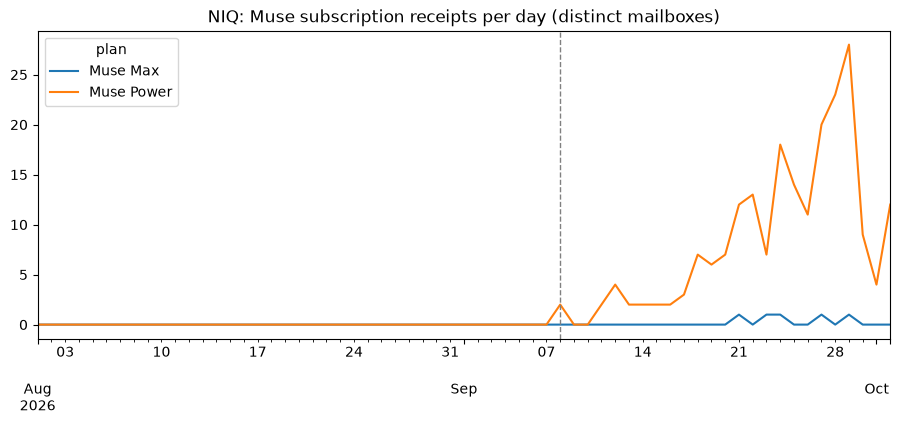

In [4]:
# Daily Muse charges by plan (NIQ). Price points seen: Power $20 (in-app), Max $100 (in-app); no $16/$80 web receipts.
muse = niq[niq.plan.str.startswith("Muse", na=False)]
daily_niq = muse[muse.kind == "charge"].pivot_table(index="order_date", columns="plan", values="mailbox_id",
                                                    aggfunc="nunique").reindex(pd.date_range(START, END)).fillna(0)
ax = daily_niq.plot(title="NIQ: Muse subscription receipts per day (distinct mailboxes)", figsize=(11, 4))
ax.axvline(pd.Timestamp(LAUNCH), color="grey", ls="--", lw=1)
daily_niq.resample("W-MON", label="left", closed="left").sum()

In [5]:
# Direct Meta receipts at $16 / $80 (expect only Quest games and ad boosts; no Muse)
q(f"""
    SELECT merchant_name, description, ROUND(item_price, 2) AS price, ROUND(order_total, 2) AS total,
           COUNT(*) AS n, COUNT(DISTINCT mailbox_id) AS mailboxes, MIN(order_date) AS first_d
    FROM {NIQ}
    WHERE order_date >= '{START}' AND merchant_name IN ('Meta', 'Facebook', 'Instagram')
      AND (ABS(item_price - 16) <= 0.01 OR ABS(item_price - 80) <= 0.01 OR ABS(order_total - 16) <= 0.01 OR ABS(order_total - 80) <= 0.01)
      AND description NOT ILIKE 'Facebook Campaign%'
    GROUP BY 1, 2, 3, 4 ORDER BY n DESC LIMIT 30
""")

,merchant_name,description,price,total,n,mailboxes,first_d
0,Instagram,Instagram post: ^name^,16.00,16.00,25,16,2026-08-03
1,Meta,OG EGG VR TITAN: 15_BundleAddOns,14.99,16.00,5,1,2026-09-26
2,Meta,Beyond Sandbox,15.99,17.11,5,5,2026-09-22
3,Instagram,Instagram post: ^name^,15.99,2000.00,5,1,2026-08-06
4,Meta,Haymaker,14.99,16.00,5,5,2026-08-03
5,Meta,Pavlov Shack,15.99,15.99,4,4,2026-08-15
6,Meta,Beyond Sandbox,15.99,15.99,4,4,2026-09-24
7,Meta,Days of Heroes: D-Day,15.99,15.99,4,4,2026-08-04
8,Meta,HARD BULLET,15.99,15.99,4,4,2026-08-14
9,Meta,Titans Clinic,15.99,15.99,3,3,2026-08-22


## 2. Card panels

The deduplicated set from `card_linkagnt_coverage.ipynb`: Yodlee feeds 3/4/6 (card + bank) plus 279 `PRIME_TAU`. 279 `PRIME` is a subset of Yodlee and is skipped.

- Match: `meta|facebook|facebk|fb\.me|muse`.
- Exclusion list: drops museums, Metairie, MetaPay P2P (`metapay*`), etc.
- `METAPAY META.COM` (no `*`) is **kept**: it is Meta's direct subscription descriptor.
- Yodlee rows are deduped on (member, date, amount), because pending and posted copies can carry different ids.

In [ ]:
def src_yodlee(feed, kind):
    return dict(name=f"Yodlee F{feed} {kind.lower()}",
                table=f"SHARE_CE_SPEND_201_PRIME_EX_TAU.FEED{feed}_PANELS.FEED{feed}_{kind}_PANELS_V1_0",
                desc_col="description", date_col="transaction_date", amt_col="amount",
                txn_id_col=f"unique_{kind.lower()}_transaction_id", member_col="unique_mem_id", merchant_col=None)

CARD_SOURCES = [
    *[src_yodlee(f, k) for f in (3, 4, 6) for k in ("CARD", "BANK")],
    dict(name="279 PRIME_TAU", table="SHARE_EARNEST_279.PRIME_TAU.SPEND_279_TRANSACTIONS_V3_0",
         desc_col="billing_description", date_col="transaction_date", amt_col="transaction_amount",
         txn_id_col="earnest_transaction_id", member_col="member_id", merchant_col="merchant"),
]

META_RE = r"(meta|facebook|facebk|fb\\.me|muse)"
EXCLUDE_RE = (r"(museum|musee|museo|museu|amuse|metapay ?\\*|metagenic|metairie|metro|metal|metacore|metamucil|metabo|"
              r"metaphys|metamora|metate|musely|musescore|winred|tithe\\.ly|new meta|dometa)")

def meta_where(col):
    return (f"REGEXP_LIKE({col}, '.*{META_RE}.*', 'i') AND NOT REGEXP_LIKE({col}, '.*{EXCLUDE_RE}.*', 'i')")

def intermediary_sql(col):
    return f"""CASE WHEN {col} ILIKE '%google%' THEN 'Google Play'
                     WHEN {col} ILIKE '%apple%' OR {col} ILIKE '%itunes%' THEN 'Apple'
                     WHEN {col} ILIKE 'pp*%' OR {col} ILIKE '%paypal%' OR {col} ILIKE '% pp*%' THEN 'PayPal'
                     WHEN {col} ILIKE '%metapay%meta.com%' THEN 'Direct (METAPAY META.COM)'
                     WHEN {col} ILIKE '%facebk%' OR {col} ILIKE '%facebookad%' THEN 'Direct (FACEBK ads)'
                     ELSE 'Direct (other)' END"""

def scan_daily(src, where_sql, days):
    """One query per day; use for the 279 tables where multi-day ILIKE scans time out."""
    return pd.concat([scan_range(src, where_sql, d.date(), d.date()) for d in days], ignore_index=True)

def scan_range(src, where_sql, start, end):
    s = src
    return q(f"""
        SELECT DISTINCT '{s['name']}' AS source, {s['member_col']} AS member, {s['date_col']}::DATE AS day,
               ROUND({s['amt_col']}, 2) AS amount, {s['desc_col']} AS description,
               {bucket_sql(s['amt_col'])} AS bucket, {intermediary_sql(s['desc_col'])} AS intermediary
        FROM {s['table']}
        WHERE {s['date_col']} BETWEEN '{start}' AND '{end}' AND {where_sql}
          AND {bucket_sql(s['amt_col'])} IS NOT NULL
    """)

card = []
for s in CARD_SOURCES:
    w = meta_where(s["desc_col"])
    card.append(scan_daily(s, w, pd.date_range(START, END)) if s["name"].startswith("279") else scan_range(s, w, START, END))
card = pd.concat(card, ignore_index=True)
card["day"] = pd.to_datetime(card.day)
card["period"] = (card.day >= LAUNCH).map({False: "pre", True: "post"})
len(card)

In [ ]:
# Pre vs post launch per bucket x intermediary, as transactions per day (pre = 38 days, post = days to END)
n_days = {"pre": (pd.Timestamp(LAUNCH) - pd.Timestamp(START)).days,
          "post": (pd.Timestamp(END) - pd.Timestamp(LAUNCH)).days + 1}
prepost = card.groupby(["intermediary", "bucket", "period"]).size().unstack("period").fillna(0)
for p in ("pre", "post"):
    prepost[f"{p}_per_day"] = prepost[p] / n_days[p]
prepost["lift"] = prepost.post_per_day / prepost.pre_per_day.replace(0, pd.NA)
prepost.sort_values("post", ascending=False)

In [ ]:
# The Muse signal: METAPAY META.COM in the web price buckets, daily, by source
muse_card = card[(card.intermediary == "Direct (METAPAY META.COM)") & card.bucket.isin(["$16 web Power", "$80 web Max"])]
daily_card = muse_card.pivot_table(index="day", columns="bucket", values="member", aggfunc="nunique") \
                      .reindex(pd.date_range(START, END)).fillna(0)
ax = daily_card.plot(title="Cards: METAPAY META.COM at $16 / $80 (distinct members per day)", figsize=(11, 4))
ax.axvline(pd.Timestamp(LAUNCH), color="grey", ls="--", lw=1)
ax.axvline(pd.Timestamp(LAUNCH) + pd.Timedelta(days=14), color="grey", ls=":", lw=1)
display(daily_card.resample("W-MON", label="left", closed="left").sum())
muse_card.groupby("source").agg(n=("member", "size"), members=("member", "nunique"), first=("day", "min"))

In [ ]:
# Same descriptor at legacy prices ($11.99 / $12.99), to show the price bucket is what isolates Muse
legacy = []
for s in [x for x in CARD_SOURCES if x["name"].startswith("Yodlee")]:
    legacy.append(q(f"""
        SELECT DISTINCT '{s['name']}' AS source, {s['member_col']} AS member, {s['date_col']}::DATE AS day, ROUND({s['amt_col']}, 2) AS amount
        FROM {s['table']}
        WHERE {s['date_col']} BETWEEN '{START}' AND '{END}' AND {s['desc_col']} ILIKE '%metapay%meta.com%'
    """))
legacy = pd.concat(legacy)
legacy["day"] = pd.to_datetime(legacy.day)
legacy["price"] = pd.cut(legacy.amount, [0, 11.5, 14, 15.5, 17.6, 79, 88, 1e6],
                         labels=["<11.5", "11.99-13.99 legacy", "14-15.5", "$16 Muse", "17.6-79", "$80 Muse", ">88"])
legacy.pivot_table(index=pd.Grouper(key="day", freq="W-MON", label="left", closed="left"), columns="price",
                   values="member", aggfunc="count", observed=False).fillna(0).astype(int)

## 3. Top descriptors for manual review

Normalised description (digits and masks stripped) with pre/post counts in the price buckets. Each row gets an automatic first-pass flag: `muse` (METAPAY META.COM in a web bucket), `in-app pass-through` (Google/Apple), `ads` (FACEBK, PayPal to Meta), or `noise`. Eyeball the `noise` rows before trusting the exclusion list.

In [ ]:
card["norm"] = (card.description.str.upper()
                .str.replace(r"[0-9#X]+", " ", regex=True)
                .str.replace(r"\s+", " ", regex=True).str.strip())

def flag(row):
    if row.intermediary == "Direct (METAPAY META.COM)" and row.bucket in ("$16 web Power", "$80 web Max"):
        return "muse"
    if row.intermediary in ("Google Play", "Apple"):
        return "in-app pass-through"
    if row.intermediary in ("Direct (FACEBK ads)", "PayPal"):
        return "ads / other Meta"
    return "noise?"

review = (card.groupby(["norm", "intermediary", "bucket", "period"]).member.nunique()
              .unstack("period").fillna(0).astype(int).reset_index())
review["flag"] = review.apply(flag, axis=1)
review["delta"] = review.get("post", 0) - review.get("pre", 0)
review.sort_values(["delta", "post"], ascending=False).head(60)